# Highest Closed DOT Contour — Single Timestep then range of times

This notebook walks through finding the highest closed contour in the Dynamic Ocean Topography (DOT) field for a single timestep, step by step.

The approach:
1. Slice the dataset to the longitude range of interest
2. Prepare and mask the DOT field
3. Generate contours at many levels
4. Filter for closed contours only
5. Find the highest level that contains closed contours
6. Plot all closed sections at that level

## Cell 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from shapely.geometry import MultiPolygon
import geopandas as gpd
from shapely.geometry import box
import matplotlib.cm as cm
import pandas as pd
from shapely.affinity import translate
from matplotlib.path import Path

path = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = path + 'Data/'
script_dir = path + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'

file_path = data_dir + 'dot_all_30bmedian_egm2008_sig3.nc'

ds = xr.open_dataset(file_path)
print(ds)
# --- Mask out bad months ---
good_months = ds['bad_month_flag'] == 0
ds = ds.isel(time=good_months)

# add SSH to the ds
ds['ssh'] = ds['dot'] + ds['sla']

# print(ds)

# --- Point cartopy directly at your local shapefiles ---
land_shp       = data_dir + 'ne_50m_land/ne_50m_land.shp'
coast_shp      = data_dir +'ne_50m_coastline/ne_50m_coastline.shp'
ice_poly_shp   = data_dir +'ne_50m_antarctic_ice_shelves_polys/ne_50m_antarctic_ice_shelves_polys.shp'
ice_lines_shp  = data_dir +'ne_50m_antarctic_ice_shelves_lines/ne_50m_antarctic_ice_shelves_lines.shp'

# --- Create cartopy features from your local files ---
land_feature      = cfeature.ShapelyFeature(shpreader.Reader(land_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='lightgray', edgecolor='none')
coast_feature     = cfeature.ShapelyFeature(shpreader.Reader(coast_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=0.8)
ice_poly_feature  = cfeature.ShapelyFeature(shpreader.Reader(ice_poly_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='lightblue', edgecolor='none', alpha=0.5)
ice_lines_feature = cfeature.ShapelyFeature(shpreader.Reader(ice_lines_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='none', edgecolor='steelblue', linewidth=0.8)


# Load shapefiles as geodataframes
land_gdf = gpd.read_file(land_shp)
coast_gdf = gpd.read_file(coast_shp)
ice_poly_gdf = gpd.read_file(ice_poly_shp)
ice_lines_gdf = gpd.read_file(ice_lines_shp)

<xarray.Dataset> Size: 249MB
Dimensions:          (longitude: 360, latitude: 64, time: 270, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2024-12-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 50MB ...
    ug               (longitude, latitude, time) float64 50MB ...
    vg               (longitude, latitude, time) float64 50MB ...
    U                (longitude, latitude, time) float64 50MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
    bad_month_flag   (time) bool 270B ...
    sla              (longitude, latitud

## Cell 2 — User Parameters

All the settings you might want to change are collected here in one place so you don't have to hunt through the code later.

- **`time_idx`** — which timestep to look at (0 = first month in the dataset)
- **`lon_min / lon_max`** — the longitude bounds of your sector. Slicing *before* contouring is what prevents the boundary-snapping issue: matplotlib never sees the edges, so it cannot connect contours across them
- **`n_levels`** — how many evenly-spaced DOT levels to try. More levels = finer resolution but slightly slower
- **`min_area`** — minimum enclosed area in degrees² to count as a real contour. Filters out tiny numerical artefacts

In [2]:
time_idx =142          # index into ds.time — change to select a different month
lon_min  = 150        # western boundary of your sector
lon_max  =  -80        # eastern boundary of your sector
n_levels = 200        # number of contour levels to test
min_area = 0.5        # minimum enclosed area (deg^2) to keep a contour
# Cell 2 — add a lat_min / lat_max
lat_min = -90   # adjust to just contain the gyre
lat_max = -50   # trim off the northern open boundary

## Cell 3 — Slice the Dataset to the Longitude Range

We select a single timestep and restrict to `[lon_min, lon_max]` and '[lat_min, lat_max]' **before** any contouring.

This is fixes the boundary-snapping problem I had before. When the full global (or wide) grid is passed to `matplotlib.contour`, it can join contour lines across the left and right edges of the array (lon min and max), creating false closed loops that straddle your sector boundary. By slicing first, those edges don't exist in the data.

In [3]:
# # Cell 3 — add latitude to the slice
crosses_dateline = True   # set to False for normal sectors (<0 then >0)

if not crosses_dateline:
    # Original approach
    ds_slice = ds.sel(
        longitude=slice(lon_min, lon_max),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )
    lons = ds_slice['longitude'].values
    lats = ds_slice['latitude'].values
    dot_2d  = ds_slice['dot'].values.T
    land_2d = ds_slice['land_mask'].values.T

else:
    # Split into two chunks either side of the dateline and concatenate
    ds_A = ds.sel(
        longitude=slice(lon_min, 180),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )
    ds_B = ds.sel(
        longitude=slice(-180, lon_max),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )

    # Shift chunk B longitudes by +360 so the axis is monotonically increasing
    ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)

    # Concatenate along longitude
    # ds_slice = xr.concat([ds_A, ds_B], dim='longitude')
    ds_slice = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')

    lons = ds_slice['longitude'].values        # now runs e.g. 150 → 210 continuously
    lats = ds_slice['latitude'].values
    dot_2d  = ds_slice['dot'].values.T
    land_2d = ds_slice['land_mask'].values.T

# Mask land — same as before
dot_2d = np.where(land_2d == 1, np.nan, dot_2d)

print(f"Longitude range: {lons[0]:.1f} to {lons[-1]:.1f}  ({len(lons)} points)")

Longitude range: 150.5 to 279.5  (130 points)


## Cell 3b — Create functions to deal with meridian-crossing sections

split_and_shift_gdf: shifts natural earth shapefiles which were loaded as geodataframes in the same way cell 3 manages the split

is_valid_contour: returns a false if the contour is weirdly meridional - this uses the aspect ratio of lon/lat width. if <0.5 then too narrow. this was made for a month before I masked the ds using the bad_month_mask

mean_inside_contour: computes the mean variable height (SSH/DOT) inside the closed contour - I think this is what Dotto, 2019 uses and will be helpful to compare against

area_deg2_to_km2: converts the calculated deg2 area (coords in degrees) to km^2 using the mean latitude of the of the contour vertices

In [22]:
def split_and_shift_gdf(gdf, lons_shifted):
    x_min, x_max = lons_shifted[0], lons_shifted[-1]
    domain = box(x_min, lat_min, x_max, lat_max)

    # Keep both original and +360 shifted versions of every geometry
    original = gdf.copy()
    shifted  = gdf.copy()
    shifted['geometry'] = shifted.geometry.apply(lambda g: translate(g, xoff=360))

    combined = pd.concat([original, shifted])

    # Clip to domain — only geometries that fall within the domain survive
    combined['geometry'] = combined.geometry.apply(
        lambda g: g.intersection(domain) if g is not None and not g.is_empty else g
    )
    combined = combined[~combined.geometry.is_empty]
    return combined

def is_valid_contour(verts, max_aspect_ratio=0.5):
    """
    Returns False if the contour is suspiciously meridional.
    max_aspect_ratio: reject if lon_span / lat_span < this value
    e.g. 0.5 means contour must be at least half as wide as it is tall
    """
    lon_span = verts[:, 0].max() - verts[:, 0].min()
    lat_span = verts[:, 1].max() - verts[:, 1].min()

    if lat_span == 0:
        return True   # flat contour, not meridional

    aspect = lon_span / lat_span
    return aspect >= max_aspect_ratio

def mean_inside_contour(verts, field_2d, lon_grid, lat_grid):
    """Compute mean of field_2d inside the closed contour verts."""
    path   = Path(verts)
    points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    mask   = path.contains_points(points).reshape(field_2d.shape)
    vals   = field_2d[mask]
    return np.nanmean(vals) if len(vals) > 0 else np.nan

def area_deg2_to_km2(area_deg2, verts):
    """
    Convert area from degrees² to km² accounting for latitude.
    Uses the mean latitude of the contour vertices.
    """
    mean_lat = np.mean(verts[:, 1])
    # 1 degree latitude ≈ 111.32 km
    # 1 degree longitude ≈ 111.32 * cos(lat) km
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(mean_lat))
    return area_deg2 * km_per_deg_lat * km_per_deg_lon

## Cell 3c

Apply split_and_shift function from 3b to the land, coast, ice, ice outlines geodataframe data

In [23]:
if crosses_dateline:
    _land = split_and_shift_gdf(land_gdf, lons)
    _coast = split_and_shift_gdf(coast_gdf, lons)
    _ice_poly = split_and_shift_gdf(ice_poly_gdf, lons)
    _ice_lines = split_and_shift_gdf(ice_lines_gdf, lons)
else:
    _land = land_gdf
    _coast = coast_gdf
    _ice_poly = ice_poly_gdf
    _ice_lines = ice_lines_gdf

## Cell 4 — Prepare the DOT Field

Two things:

1. **Transpose** — the dataset stores DOT as `(longitude, latitude)`, but `matplotlib.contour` expects `(row, col)` = `(latitude, longitude)`, so transpose with `.T`
2. **Land mask** — land points are set to `NaN` so they are invisible to the contouring algorithm. Without this, contour lines would run across land, which lead to the problem i had before

In [24]:
dot_2d  = ds_slice['dot'].values.T         # shape becomes (n_lat, n_lon)
land_2d = ds_slice['land_mask'].values.T   # same shape

# Set land points to NaN — contour ignores NaN
dot_2d = np.where(land_2d == 1, np.nan, dot_2d)

print(f"DOT shape (lat x lon): {dot_2d.shape}")
print(f"DOT range:  {np.nanmin(dot_2d):.4f} to {np.nanmax(dot_2d):.4f} m")
print(f"NaN (land/missing) points: {np.sum(np.isnan(dot_2d))} of {dot_2d.size}")

DOT shape (lat x lon): (64, 130)
DOT range:  -2.3706 to -0.2665 m
NaN (land/missing) points: 2046 of 8320


## Cell 5 — DOT Plot

Before running the contour algorithm I visually inspect the DOT field for a sanity-check of the masking and .T function (and to get a feel for the DOT range).

2 plots produced:
1. DOT field using shifted DOT coordinates
2. DOT field with the ice, coast, land, and ice outlines plotted on a real-world coordinate system

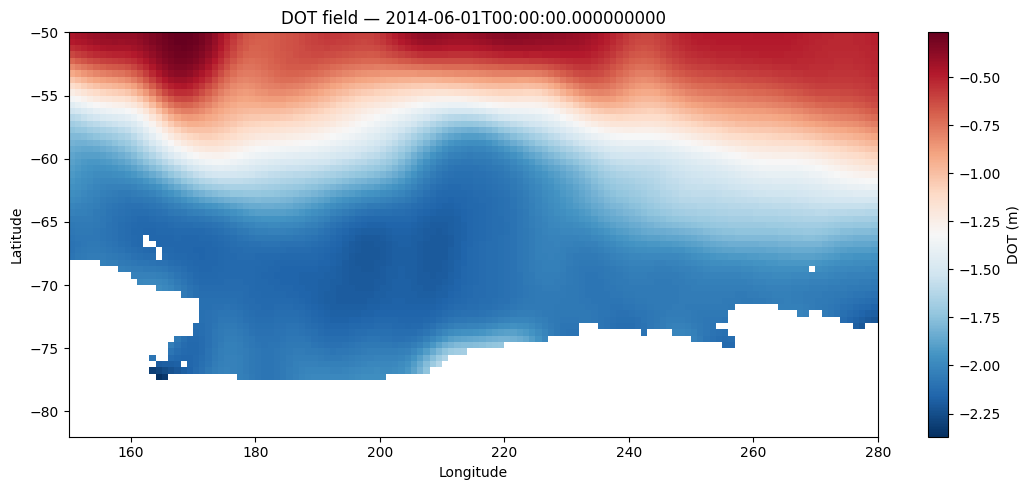

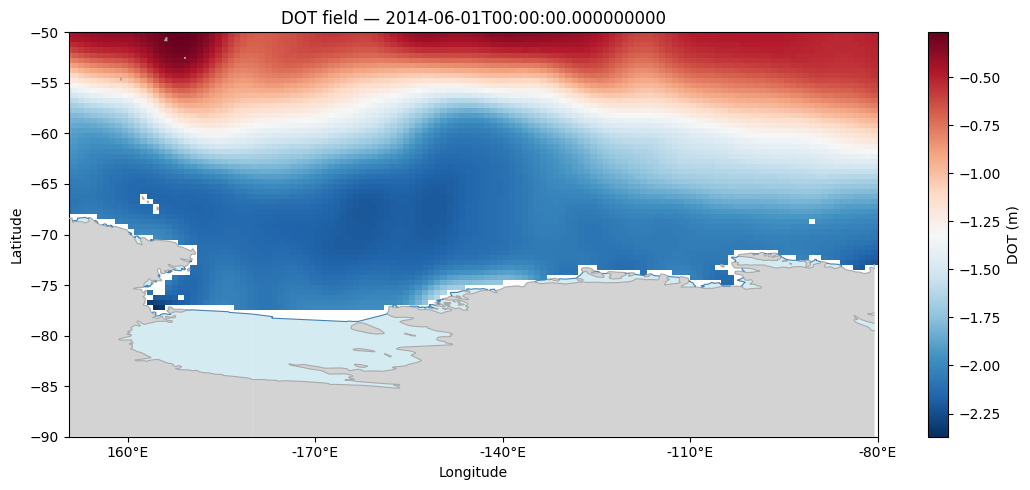

In [25]:
lon_grid, lat_grid = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(11, 5))
pcm = ax.pcolormesh(lon_grid, lat_grid, dot_2d, cmap='RdBu_r', shading='auto')
plt.colorbar(pcm, ax=ax, label='DOT (m)')
ax.set_title(f'DOT field — {ds.time[time_idx].values}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(11, 5))

pcm = ax.pcolormesh(lon_grid, lat_grid, dot_2d, cmap='RdBu_r', shading='auto', zorder=1)

_land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
_coast.plot(ax=ax,     color='darkgray',      edgecolor='black', linewidth=0.8, zorder=3)
_ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
_ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)

ax.set_aspect('auto')
ax.set_xlim(lons[0], lons[-1])
ax.set_ylim(lat_min, lat_max)

if crosses_dateline:
    # Generate ticks at round numbers within your actual data range
    tick_vals = np.arange(np.ceil(lons[0]/10)*10, lons[-1]+1, 30)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f'{int(x-360)}°E' if x > 180 else f'{int(x)}°E' for x in tick_vals])
else:
    ax.set_xlabel('Longitude')

plt.colorbar(pcm, ax=ax, label='DOT (m)')
ax.set_title(f'DOT field — {ds.time[time_idx].values}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()




## Cell 6 — Generate Contours

`matplotlib.contour` traces isolines at each level across the 2D field. Pass `n_levels` evenly-spaced values between the min and max of the DOT field.

The `cs` contour object is needed to extract path geometry; I plot it here to check the correct contour is selected below.

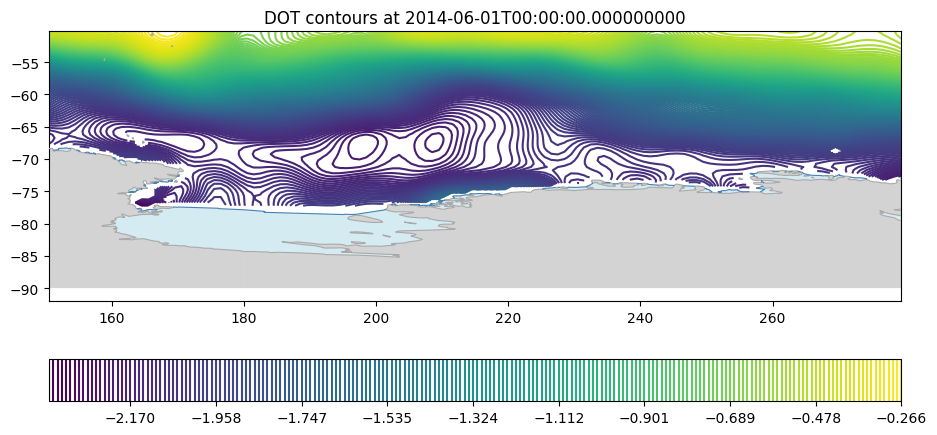

Generated 200 contour levels
Level range: -2.3706 to -0.2665 m
Level spacing: 0.01057 m


In [26]:
levels = np.linspace(np.nanmin(dot_2d), np.nanmax(dot_2d), n_levels)

fig, ax = plt.subplots(figsize=(11, 5))
cs = ax.contour(lon_grid, lat_grid, dot_2d, levels=levels)
plt.colorbar(cs, orientation='horizontal')
plt.title(f'DOT contours at {ds.time[time_idx].values}')

_land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
_coast.plot(ax=ax,     color='darkgray',      edgecolor='black', linewidth=0.8, zorder=3)
_ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
_ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)
ax.set_aspect('auto')

plt.show()
plt.close(fig)


print(f"Generated {len(cs.levels)} contour levels")
print(f"Level range: {cs.levels[0]:.4f} to {cs.levels[-1]:.4f} m")
print(f"Level spacing: {np.diff(cs.levels).mean():.5f} m")

## Cell 7 — Identify Closed Contours - the deepest closed contours

Each level in `cs` can have multiple paths (line segments). A path is **closed** if its first and last vertex are the same point — i.e. it forms a loop.

For each closed path I compute its **enclosed area** using the shoelace formula:

$$A = \frac{1}{2} \left| \sum_{i} (x_i y_{i+1} - y_i x_{i+1}) \right|$$

This gives area in degrees sqaured (since the coordinates are lon/lat in degrees). I use `min_area` to discard tiny artefacts.

I iterate **from low to high** and stop as soon as we find a level that has at least one valid closed contour — this is the deepest closed level.

In [27]:
best_level = None
best_paths = []

# cs.allsegs is a list of lists: cs.allsegs[i] = all segments at cs.levels[i]
# each segment is a (N, 2) numpy array of (lon, lat) points
for level, segs in zip((cs.levels), (cs.allsegs)):
    closed_at_this_level = []

    for verts in segs:
        if len(verts) == 0:   # skip empty segments
            continue

        # --- Closed check ---
        is_closed = np.allclose(verts[0], verts[-1], atol=1e-6)

        if is_closed:
            # --- Shoelace area ---
            x, y = verts[:, 0], verts[:, 1]
            area = 0.5 * np.abs(
                np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
            )
            if area >= min_area:
                closed_at_this_level.append((area, verts))

    if closed_at_this_level:
        best_level = level
        best_paths = sorted(closed_at_this_level, key=lambda t: t[0], reverse=True)
        break

# --- Report ---
if best_level is not None:
    print(f"Deepest closed DOT level: {best_level:.4f} m")
    print(f"Number of closed sections at this level: {len(best_paths)}")
    for i, (area, verts) in enumerate(best_paths):
        cx = verts[:, 0].mean()
        cy = verts[:, 1].mean()
        print(f"  Section {i+1}: area = {area:.2f} deg², centroid ≈ ({cx:.1f}°, {cy:.1f}°)")
else:
    print("No closed contours found. Try lowering min_area or adjusting lon_min/lon_max.")

Deepest closed DOT level: -2.2014 m
Number of closed sections at this level: 2
  Section 1: area = 13.03 deg², centroid ≈ (197.9°, -68.1°)
  Section 2: area = 6.00 deg², centroid ≈ (208.7°, -67.6°)


## Cell 7b — Plot the Result

Plot the DOT field as a background and overlay each closed section in a different colour. If the gyre is split into two lobes at the highest closed level, both will be plotted in an attempt to capture gyre splitting.

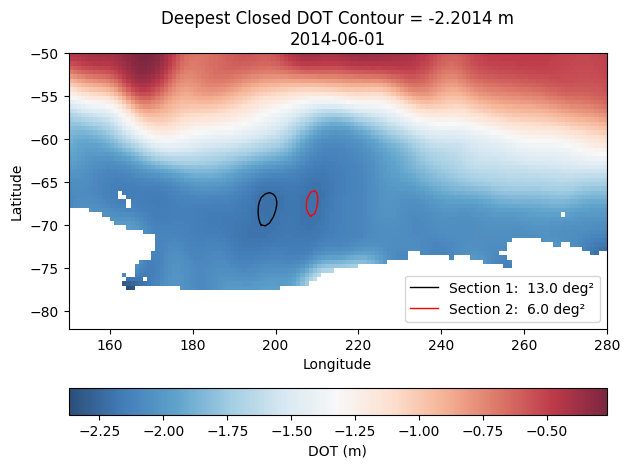

Deepest closed contour height:, -2.2014m


In [29]:
colors = ['black', 'red', 'blue', 'orange', 'green', 'purple']

fig, ax = plt.subplots()
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

pcm = ax.pcolormesh(lon_grid, lat_grid, dot_2d, cmap='RdBu_r', shading='auto', alpha=0.85)
plt.colorbar(pcm, ax=ax, label='DOT (m)', orientation='horizontal')

if best_paths:
    for i, (area, verts) in enumerate(best_paths):
        color = colors[i % len(colors)]
        ax.plot(
            verts[:, 0], verts[:, 1],
            color=color, linewidth=1,
            label=f'Section {i+1}:  {area:.1f} deg²'
        )

    ax.set_title(
        f'Deepest Closed DOT Contour = {best_level:.4f} m\n'
        f'{str(ds.time[time_idx].values)[:10]}'
    )
else:
    ax.set_title('No closed contours found')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower right')
# ax.coastlines()
plt.tight_layout()
plt.show()

print(f'Deepest closed contour height:, {best_level:.4f}m')

## Cell 8 — Identify Closed Contours - the largest closed contour (using area)

Each level in `cs` can have multiple paths (line segments). A path is **closed** if its first and last vertex are the same point — i.e. it forms a loop.



In [59]:
best_area_level = None
best_area_paths = []
all_closed = []   # collect ALL closed contours across ALL levels

for level, segs in zip(cs.levels, cs.allsegs):
    for verts in segs:
        if len(verts) == 0:
            continue

        is_closed = np.allclose(verts[0], verts[-1], atol=1e-6)

        if is_closed:
            x, y = verts[:, 0], verts[:, 1]
            area = 0.5 * np.abs(
                np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
            )
            if area >= min_area:
                all_closed.append((area, level, verts))

# Sort by area, largest first
all_closed.sort(key=lambda t: t[0], reverse=True)

if all_closed:
    largest_area, largest_level, largest_verts = all_closed[0]
    print(f"Largest closed contour:")
    print(f"  DOT level : {largest_level:.4f} m")
    print(f"  Area      : {largest_area:.2f} deg²")
    cx = largest_verts[:, 0].mean()
    cy = largest_verts[:, 1].mean()
    print(f"  Centroid  : ({cx:.1f}°, {cy:.1f}°)")
else:
    print("No closed contours found.")

Largest closed contour:
  DOT level : -2.1380 m
  Area      : 256.12 deg²
  Centroid  : (198.9°, -68.8°)


## Cell 8b — Plot the Result

Plot the DOT field as a background and overlay each closed section in a different colour. I do not have the 'track-splitting' capability yet

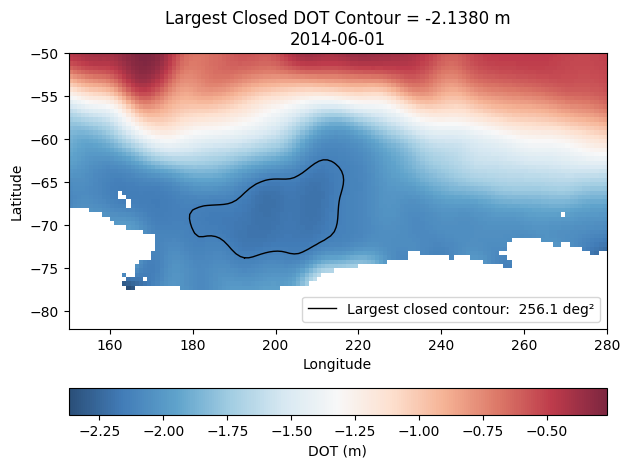

In [60]:
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig, ax = plt.subplots()
pcm = ax.pcolormesh(lon_grid, lat_grid, dot_2d, cmap='RdBu_r', shading='auto', alpha=0.85)
plt.colorbar(pcm, ax=ax, label='DOT (m)', orientation='horizontal')

if all_closed:
    ax.plot(
        largest_verts[:, 0], largest_verts[:, 1],
        color='black', linewidth=1,
        label=f'Largest closed contour:  {largest_area:.1f} deg²'
    )
    ax.set_title(
        f'Largest Closed DOT Contour = {largest_level:.4f} m\n'
        f'{str(ds.time[time_idx].values)[:10]}'
    )
else:
    ax.set_title('No closed contours found')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower right')
# ax.coastlines()
plt.tight_layout()
plt.show()

## Cell 9 - Full timeseries (full ds) processing: Closed-Contour Detection using the area method


Iterates over every timestep in `ds`, extracts the spatial slice (dateline-aware), calculates contours on the DOT field, and stores the best (largest area) closed contour per timestep in `all_timestep_results`.

**Spatial slicing**
- If the region does not cross the dateline, a single `ds.sel()` slice is taken directly as lon_min < lon_max.
- If it does cross the dateline, the region is split into two sub-slices (`ds_A`: up to 180°, `ds_B`: from −180°), the western chunk's longitudes are shifted by +360°, and the two are concatenated along the `longitude` dimension via `xr.concat`. This is to account and correct for the ds -180 to 180 longitude range and ensure contours are detected across the meridian.
- `land_mask` is applied to both `dot_2d` and `ssh_2d` (land pixels → `NaN`) after slicing to prevent the 'jumping' I had earlier.

**Guard clause**
- Timesteps where the valid DOT range is degenerate (non-finite or zero-width) are skipped and logged; a `found: False` entry is appended.

**Contour extraction**
- `np.linspace(dot_min, dot_max, n_levels)` generates evenly spaced contour levels across the valid DOT range.
- A throwaway `ax.contour()` figure is opened and immediately closed (`plt.close`) — useful to extract `cs_i.allsegs`.
- A contour segment is classified as **closed** if its first and last vertices are coincident within the tolerance: `atol=1e-6`.
- The shoelace formula computes the enclosed area in deg squared.
- Closed contours are additionally filtered by `is_valid_contour()` (aspect ratio ≤ 0.5) to exclude elongated or degenerate shapes (not really necessary now due to applying 'bad_month_mask'.

**Result selection**
- All valid closed contours for a timestep are sorted by area descending; the largest (`all_closed_i[0]`) is selected as the best candidate.
- Use `mean_inside_contour()` to calculate the mean SSH value over the interior of the best contour ( I think this is what Dotto, 2019 does so could be good for comparison).
- Each result dict stores: `time`, `time_idx`, `area` (deg²), `area_km2`, `level` (m), `verts`, `ssh_mean`, and `found`.

**Progress logging**
- A progress line is printed every 20 timesteps, with a final summary of how many timesteps yielded a closed contour.



In [30]:
all_timestep_results = []

for time_idx_i, time_val in enumerate(ds.time.values):

    # --- Dateline-aware slice ---
    if not crosses_dateline:
        ds_slice_i = ds.sel(
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_min, lat_max),
            time=ds.time[time_idx_i]
        )
        lons_i = ds_slice_i['longitude'].values
        lats_i = ds_slice_i['latitude'].values
        dot_2d_i  = ds_slice_i['dot'].values.T
        ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
        land_2d_i = ds_slice_i['land_mask'].values.T

    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        # ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude')
        ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i = ds_slice_i['longitude'].values
        lats_i = ds_slice_i['latitude'].values
        dot_2d_i  = ds_slice_i['dot'].values.T
        ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
        land_2d_i = ds_slice_i['land_mask'].values.T

    dot_2d_i = np.where(land_2d_i == 1, np.nan, dot_2d_i)
    ssh_2d_i = np.where(land_2d_i == 1, np.nan, ssh_2d_i)
    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)

    # --- Guard: skip if not enough valid data to contour ---
    dot_min = np.nanmin(dot_2d_i)
    dot_max = np.nanmax(dot_2d_i)
    if not np.isfinite(dot_min) or not np.isfinite(dot_max) or dot_max <= dot_min:
        print(f"Skipping {str(time_val)[:10]} — insufficient valid data")
        all_timestep_results.append({'time': time_val, 'time_idx': time_idx_i, 'found': False})
        continue

    levels_i = np.linspace(dot_min, dot_max, n_levels)

    fig, ax = plt.subplots()
    cs_i = ax.contour(lon_grid_i, lat_grid_i, dot_2d_i, levels=levels_i)
    plt.close(fig)

    all_closed_i = []
    for level, segs in zip(cs_i.levels, cs_i.allsegs):
        for verts in segs:
            if len(verts) == 0:
                continue
            if np.allclose(verts[0], verts[-1], atol=1e-6):
                x, y = verts[:, 0], verts[:, 1]
                area = 0.5 * np.abs(
                    np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
                )
                # if area >= min_area:
                #     all_closed_i.append((area, level, verts))

                if area >= min_area and is_valid_contour(verts, max_aspect_ratio=0.5):
                    all_closed_i.append((area, level, verts))

    all_closed_i.sort(key=lambda t: t[0], reverse=True)

    if all_closed_i:
            best = all_closed_i[0]
            best_verts = best[2]

            ssh_mean = mean_inside_contour(
                best_verts, ssh_2d_i, lon_grid_i, lat_grid_i
            )

            all_timestep_results.append({
                'time'    : time_val,
                'time_idx': time_idx_i,
                'area'    : best[0],
                'level'   : best[1],
                'verts'   : best[2],
                'area_km2': area_deg2_to_km2(best[0], best[2]),
                'ssh_mean': ssh_mean,
                'found'   : True
            })
    else:
        all_timestep_results.append({
            'time'    : time_val,
            'time_idx': time_idx_i,
            'found'   : False
        })

    if time_idx_i % 20 == 0:
        print(f"Processed {time_idx_i+1}/{len(ds.time.values)}  —  {str(time_val)[:10]}")

print(f"\nDone. {sum(r['found'] for r in all_timestep_results)} of {len(all_timestep_results)} timesteps have a closed contour.")

Processed 1/268  —  2002-07-01
Processed 21/268  —  2004-03-01
Processed 41/268  —  2005-11-01
Processed 61/268  —  2007-07-01
Processed 81/268  —  2009-03-01
Processed 101/268  —  2010-11-01
Processed 121/268  —  2012-07-01
Processed 141/268  —  2014-03-01
Processed 161/268  —  2015-12-01
Processed 181/268  —  2017-08-01
Processed 201/268  —  2019-04-01
Processed 221/268  —  2020-12-01
Processed 241/268  —  2022-08-01
Processed 261/268  —  2024-05-01

Done. 268 of 268 timesteps have a closed contour.


## Cell 10 - Select the time(s) for timeseries plotting

I have three options here:

'single' = one timestep, I have defined this in cell 2 as `time_idx` but need to use this in `plot_selection` in the cell

'range' = the range of time indices I am interested in. Set the range in `plot_selection` (using a comma to separate)

'all' = 'saves' all valid times (with a valid contour) into to_plot array

In [34]:
# --- Options ---
# 'single'  : one timestep by index, e.g. plot_selection = 0
# 'range'   : a range of timestep indices, e.g. plot_selection = (0, 24)
# 'all'     : every timestep with a valid contour

plot_mode      = 'all'        # 'single', 'range', or 'all'
plot_selection = (112)        # used for 'single' (int) or 'range' (tuple)

# --- Build list of results to plot ---
if plot_mode == 'single':
    to_plot = [all_timestep_results[plot_selection]]
elif plot_mode == 'range':
    start, end = plot_selection
    to_plot = all_timestep_results[start:end+1]
elif plot_mode == 'all':
    to_plot = all_timestep_results

to_plot = [r for r in to_plot if r['found']]   # drop timesteps with no contour
print(f"Plotting {len(to_plot)} timestep(s)")

Plotting 268 timestep(s)


## Cell 11 — Multi-Timestep Contour Plot with Geophysical Overlays

Produces a single composite figure showing all selected closed contours overlaid on a DOT background, with land, coastline, and sea-ice shapefiles rendered on top.

**Background field**
- The DOT field of the mean of all dot values in `to_plot` is used as the reference background.
- The same dateline-aware slicing logic from Cell 9 is applied: direct `ds.sel()` for non-dateline regions, or a split/shift/concat for regions crossing 180°.
- Land pixels are masked to `NaN` via `land_mask` before plotting.
- Rendered as a `pcolormesh` with the `RdBu_r` colormap at 70% opacity (`zorder=1`).

**Shapefile overlays** (plotted in `zorder` order above the field)
- `_land` — filled light-grey polygons, no edge (`zorder=2`)
- `_coast` — black coastline edges at 0.8 pt (`zorder=3`)
- `_ice_poly` — light-blue filled sea-ice polygons at 50% opacity (`zorder=2`)
- `_ice_lines` — steel-blue sea-ice edge lines at 0.8 pt (`zorder=3`)

**Dateline tick correction**
- If `crosses_dateline` is `True`, x-tick values above 180° are relabelled by subtracting 360° (e.g. 200° to −160°E) to display conventional longitudes.

**Contour colouring**
- Each contour in `to_plot` is assigned a colour drawn from the `viridis` colormap, linearly mapped across the timestep index (`i / (n−1)`).
- A `ScalarMappable` dummy object drives a vertical colorbar showing the timestep index range.
- Date labels are added to the legend only in `single` or `range` mode with 12 or fewer timesteps.

**Title and legend logic**
- `single` — shows the one timestep date.
- `range` — shows the first-to-last date span.
- `all` — generic title; legend suppressed to avoid overcrowding.

## Cell 11a - Calcualte the mean DOT for the selected time series

In [35]:
dot_stack = []
for result in to_plot:
    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        dot_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i['dot'].values.T)
        lons_ref = ds_i['longitude'].values
        lats_ref = ds_i['latitude'].values
    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        dot_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i['dot'].values.T)
        lons_ref = ds_i['longitude'].values
        lats_ref = ds_i['latitude'].values
    dot_stack.append(dot_i)

dot_mean = np.nanmean(np.stack(dot_stack, axis=0), axis=0)  # shape: (lat, lon)
lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)

/var/folders/_b/mwrrgwfd7k53y4lg7_zfzvjm0000gp/T/ipykernel_48189/1210241373.py:24: RuntimeWarning: Mean of empty slice
  dot_mean = np.nanmean(np.stack(dot_stack, axis=0), axis=0)  # shape: (lat, lon)


## Cell 11b - Run code to plot all closed contours in to_plot

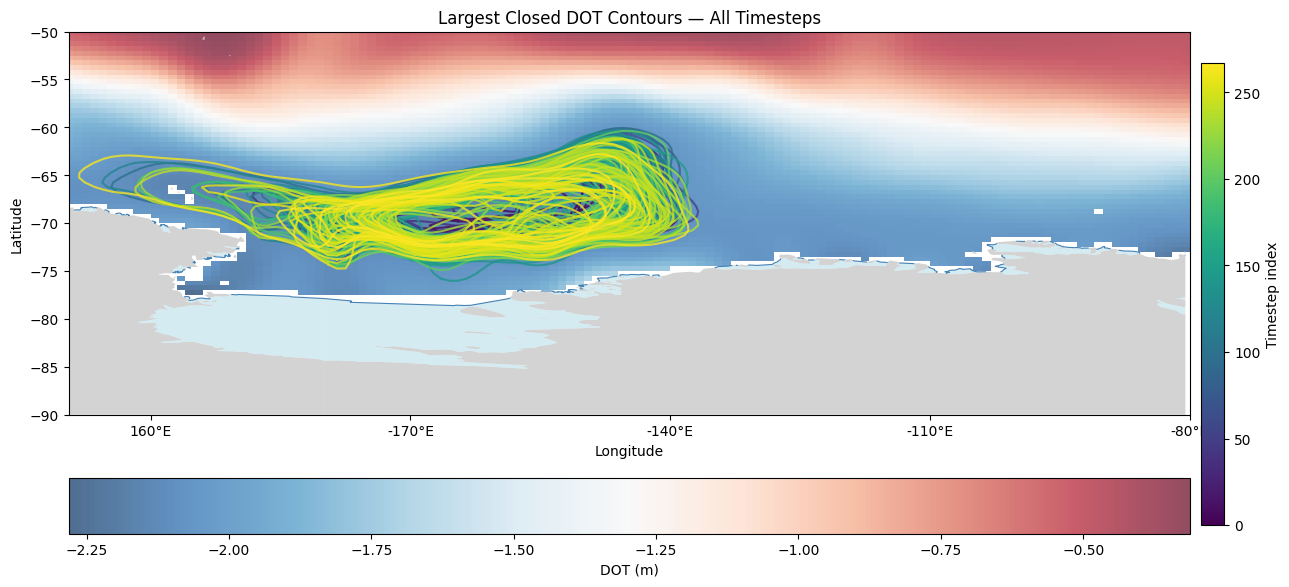

In [36]:
fig, ax = plt.subplots(figsize=(13, 6))

# Background — use the first selected timestep's DOT field with dateline-aware slice
ref = to_plot[0]

if not crosses_dateline:
    ds_ref = ds.sel(
        longitude=slice(lon_min, lon_max),
        latitude=slice(lat_min, lat_max),
        time=ds.time[ref['time_idx']]
    )
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    dot_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref['dot'].values.T)
else:
    ds_A = ds.sel(longitude=slice(lon_min, 180),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds.sel(longitude=slice(-180, lon_max),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
    ds_ref = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    dot_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref['dot'].values.T)

lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)

pcm = ax.pcolormesh(lon_grid_ref, lat_grid_ref, dot_mean, cmap='RdBu_r', shading='auto', alpha=0.7, zorder=1)

# Shapefiles
_land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
_coast.plot(ax=ax,     color='none',      edgecolor='black', linewidth=0.8, zorder=3)
_ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
_ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)

ax.set_aspect('auto')
ax.set_xlim(lons_ref[0], lons_ref[-1])
ax.set_ylim(lat_min, lat_max)

if crosses_dateline:
    tick_vals = np.arange(np.ceil(lons_ref[0]/10)*10, lons_ref[-1]+1, 30)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f'{int(x-360)}°E' if x > 180 else f'{int(x)}°E' for x in tick_vals])

# Colour-map contours by time
cmap_t = cm.viridis
n      = len(to_plot)

for i, result in enumerate(to_plot):
    color = cmap_t(i / max(n - 1, 1))
    label = str(result['time'])[:10] if plot_mode in ('single', 'range') and n <= 12 else None
    ax.plot(
        result['verts'][:, 0], result['verts'][:, 1],
        color=color, linewidth=1.5, alpha=0.8, label=label, zorder=4
    )

sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
sm.set_array([])
cbar_t = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.02)
cbar_t.set_label('Timestep index')
plt.colorbar(pcm, ax=ax, label='DOT (m)', orientation='horizontal', pad=0.12)

if plot_mode == 'single':
    ax.set_title(f'Largest Closed DOT Contour\n{str(to_plot[0]["time"])[:10]}')
elif plot_mode == 'range':
    ax.set_title(f'Largest Closed DOT Contours — {str(to_plot[0]["time"])[:10]} to {str(to_plot[-1]["time"])[:10]}')
else:
    ax.set_title('Largest Closed DOT Contours — All Timesteps')

if plot_mode in ('single', 'range') and n <= 12:
    ax.legend(loc='lower right', fontsize=8)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Cell 12a — Gyre Timeseries Plot (for the sub-series)

Extracts three scalar timeseries from `to_plot` and renders them as a stacked 3-plot figure, one plot per variable.
**Data extraction**
- `times`, `levels`, `areas` pulled directly from each result dict.
- `ssh_vals` drawn from `ssh_mean` — the mean SSH inside the best closed contour computed in Cell 9.
- `areas_km2` converted from raw deg² values via `area_deg2_to_km2()`, then scaled by `1e-6` for display in units of 10⁶ km².

**Plots** ( share the x-axis)
- **Top** — mean SSH inside the gyre (m), `steelblue`
- **Middle** — gyre area (10⁶ km²), `red`
- **Bottom** — DOT contour level of the best closed contour (m), `darkorange`

Each panel includes a dashed grey `axhline` at the `nanmean` of that variable over the plotted period, providing a quick visual reference for the time-mean.

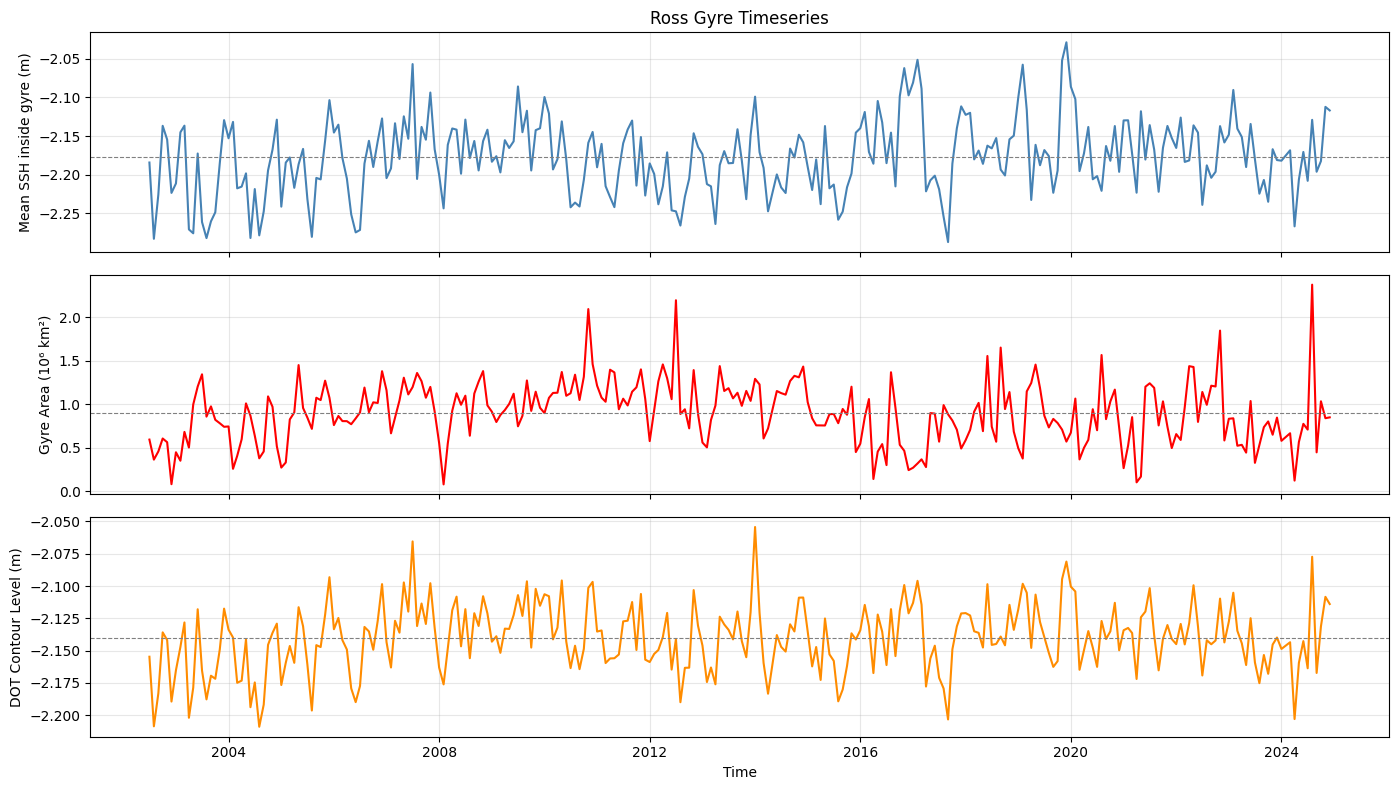

In [37]:
times = [r['time'] for r in to_plot]
areas = [r['area']  for r in to_plot]
levels = [r['level']  for r in to_plot]
ssh_vals = [r['ssh_mean'] for r in to_plot]

areas_km2 = [r['area_km2'] / 1e6 for r in to_plot]   # convert to 10^6 km²

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(times, ssh_vals, color='steelblue', linewidth=1.5)
axes[0].axhline(np.nanmean(ssh_vals), color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Mean SSH inside gyre (m)')
axes[0].set_title('Ross Gyre Timeseries')
axes[0].grid(True, alpha=0.3)

# axes[1].plot(times, areas, color='red', linewidth=1.5)
# axes[1].axhline(np.nanmean(areas), color='gray', linewidth=0.8, linestyle='--')
# axes[1].set_ylabel('Gyre Area (deg²)')
# axes[1].grid(True, alpha=0.3)

axes[1].plot(times, areas_km2, color='red', linewidth=1.5)
axes[1].axhline(np.nanmean(areas_km2), color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Gyre Area (10⁶ km²)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, levels, color='darkorange', linewidth=1.5)
axes[2].axhline(np.nanmean(levels), color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('DOT Contour Level (m)')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 12b — Gyre Timeseries Plot (for the full time series)

only different to 12a when using 'single' and 'range'

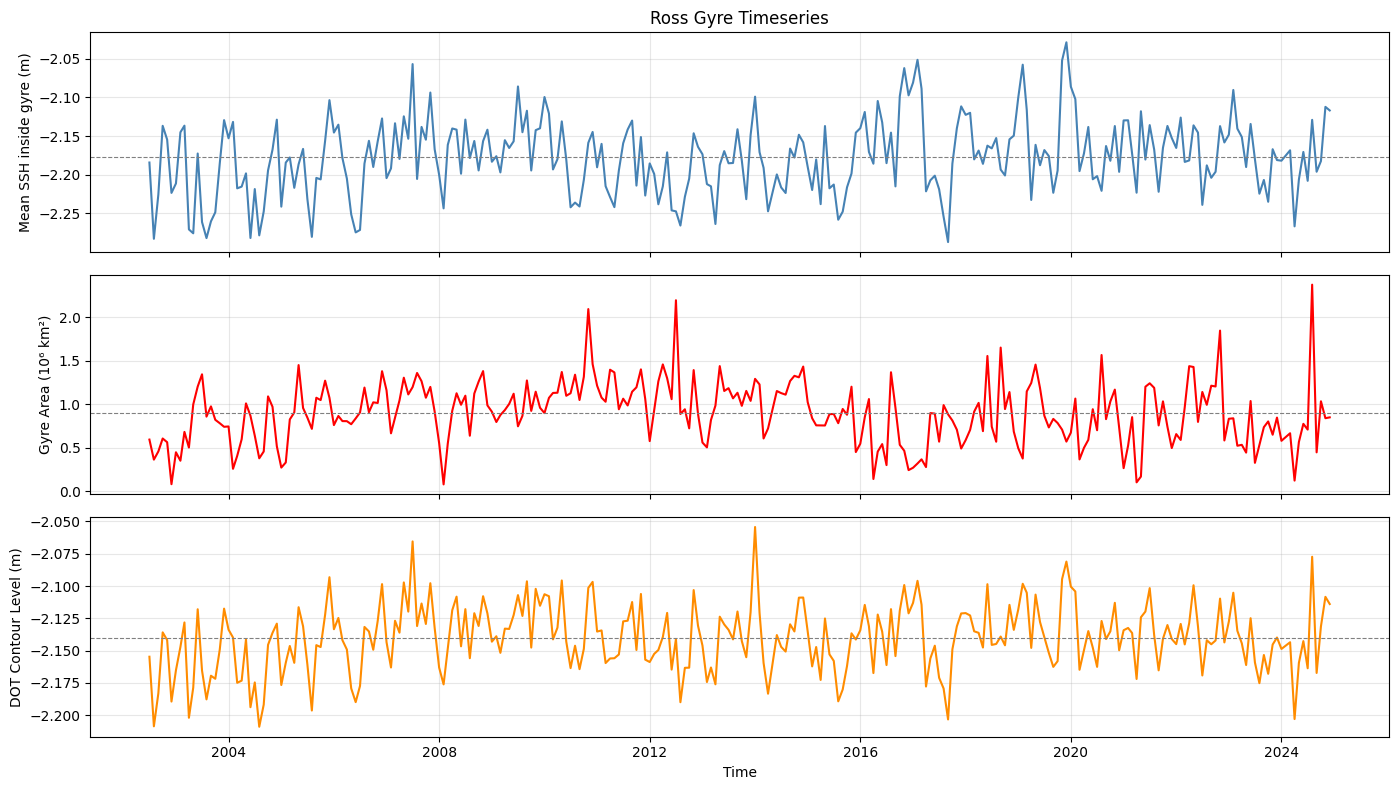

In [38]:
# Extract timeseries from all_timestep_results (use this, not to_plot, for full timeseries)
times  = [r['time']  for r in all_timestep_results if r['found']]
areas  = [r['area']  for r in all_timestep_results if r['found']]
levels = [r['level'] for r in all_timestep_results if r['found']]
ssh_vals = [r['ssh_mean'] for r in all_timestep_results if r['found']]


areas_km2 = [r['area_km2'] / 1e6 for r in all_timestep_results if r['found']]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(times, ssh_vals, color='steelblue', linewidth=1.5)
axes[0].axhline(np.nanmean(ssh_vals), color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Mean SSH inside gyre (m)')
axes[0].set_title('Ross Gyre Timeseries')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, areas_km2, color='red', linewidth=1.5)
axes[1].axhline(np.nanmean(areas_km2), color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Gyre Area (10⁶ km²)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, levels, color='darkorange', linewidth=1.5)
axes[2].axhline(np.nanmean(levels), color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('DOT Contour Level (m)')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()